In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import sys
sys.path.append("..")
from src.preprocessing import regrouper_categories_rares, traitement_valeurs_incohérentes, zero_vers_nan, Transformation_binaire, remplacer_au_dessus_seuil, fusionner_categories
print("Environnement prêt")

Environnement prêt


In [2]:
df = pd.read_csv("../data/raw/bluebook-for-bulldozers/TrainAndValid.csv",
                 low_memory=False)

In [3]:
df.shape

(412698, 53)

In [4]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.dtypes

SalesID                       int64
SalePrice                   float64
MachineID                     int64
ModelID                       int64
datasource                    int64
auctioneerID                float64
YearMade                      int64
MachineHoursCurrentMeter    float64
UsageBand                       str
saledate                        str
fiModelDesc                     str
fiBaseModel                     str
fiSecondaryDesc                 str
fiModelSeries                   str
fiModelDescriptor               str
ProductSize                     str
fiProductClassDesc              str
state                           str
ProductGroup                    str
ProductGroupDesc                str
Drive_System                    str
Enclosure                       str
Forks                           str
Pad_Type                        str
Ride_Control                    str
Stick                           str
Transmission                    str
Turbocharged                

## 2 - Comprendre les données

In [6]:
df["SalesID"].nunique()

412698

In [7]:
df.shape[0]

412698

Unité d'observation

Une ligne correspond à une transaction de vente aux enchères d'un engin.
'SalesID' est unique (412 698 valeurs distinctes = 412 698 lignes).

In [8]:
df["MachineID"].nunique()


348808

In [9]:
df["MachineID"].value_counts().head(100)


MachineID
2283592    48
2285830    44
1896854    40
1746392    34
2268800    31
           ..
2303682    13
2271989    13
2269961    13
2296171    13
2267787    13
Name: count, Length: 100, dtype: int64

In [10]:
counts = df["MachineID"].value_counts()


In [11]:
(counts > 1).sum()/len(counts)

np.float64(0.13398775257448223)

Identifiants

- 'SalesID' est unique : une ligne = une transaction.
- 348 808 machines distinctes pour 412 698 transactions.
- 46 736 machines (13%) apparaissent plusieurs fois.
- Risque de fuite limité par le split temporel : on entraîne sur le passé, on teste sur le futur.

In [12]:
df["saledate"] = pd.to_datetime(df["saledate"])


In [13]:
df["saledate"].dt.year
print(df["saledate"].min())
print(df["saledate"].max())
print(df["saledate"].dt.year.value_counts().sort_index())

1989-01-17 00:00:00
2012-04-28 00:00:00
saledate
1989     4806
1990     4529
1991     5109
1992     5519
1993     6303
1994     7929
1995     8530
1996     8829
1997     9785
1998    13046
1999    12793
2000    17415
2001    17594
2002    17246
2003    15254
2004    19879
2005    20463
2006    21685
2007    32208
2008    39767
2009    43849
2010    33390
2011    35197
2012    11573
Name: count, dtype: int64


In [14]:
df.groupby("ProductGroup")["MachineHoursCurrentMeter"] \
  .apply(lambda x: x.isnull().mean() * 100) \
  .sort_values(ascending=False)

ProductGroup
BL     66.634317
MG     64.932592
TTT    63.995786
TEX    63.964310
WL     63.893138
SSL    61.327231
Name: MachineHoursCurrentMeter, dtype: float64

2.7  Synthèse des limites globales du dataset

Le dataset contient 412 698 observations. `SalesID` est unique et correspond à l'unité d'observation (une ligne = une transaction de vente).

 MachineID  est dupliqué chez 13% des lignes : une même machine peut être vendue plusieurs fois au cours du temps. MachineID est donc un identifiant, jamais une feature.

 Valeurs manquantes  deux origines distinctes : 
- Certaines colonnes (ex: `Pushblock`, 93% de NaN) sont structurellement vides car l'attribut ne s'applique qu'à certains types d'engins (typologie de matériel).
- `MachineHoursCurrentMeter` en revanche présente un taux de NaN proche entre tous les ProductGroup (61 à 66%) : l'absence n'est donc pas liée au type d'engin mais plutôt à un problème de collecte/déclaration.
  - 265 194 valeurs manquantes (64%)
  - 73 834 valeurs égales à zéro à traiter comme manquantes (non déclaré selon le dictionnaire)
  - Décision : convertir les zéros en NaN dans le pipeline, créer un indicateur binaire `hours_reported`

 Période temporelle :  les données couvrent janvier 1989 à avril 2012. La collecte s'arrête au 28 avril 2012, pas en fin d'année  2012 n'est donc pas une année complète (11 573 lignes contre 35 197 en 2011).

 Split train/test :  train sur 1989-2011, test sur la partie disponible de 2012. Ce split temporel limite la fuite de données (le modèle ne doit jamais voir le futur pendant l'entraînement) et reproduit une situation réaliste de déploiement en entreprise.

 Limite du test set 2012 :  le volume (11 573 lignes) est suffisant pour une estimation stable de la MAE/RMSE. En revanche, le test set ne couvre que janvier-avril, ce qui peut introduire un biais de représentativité si les ventes ont une saisonnalité marquée (composition en ProductGroup ou niveaux de prix différents selon la période de l'année). Ce point est à surveiller lors de l'évaluation du modèle.

## 3 - Exploration de la base

In [15]:
df["YearMade"].describe()


count    412698.000000
mean       1899.049637
std         292.190243
min        1000.000000
25%        1985.000000
50%        1995.000000
75%        2001.000000
max        2014.000000
Name: YearMade, dtype: float64

In [16]:
df["YearMade"][df["YearMade"]>2012].value_counts()/len(df["YearMade"])

YearMade
2014    0.000005
2013    0.000002
Name: count, dtype: float64

In [17]:
df["YearMade"][df["YearMade"]==1000].value_counts()/len(df["YearMade"])

YearMade
1000    0.095448
Name: count, dtype: float64

In [18]:
df["MachineHoursCurrentMeter"].describe()  

count    1.475040e+05
mean     3.522988e+03
std      2.716993e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.209000e+03
max      2.483300e+06
Name: MachineHoursCurrentMeter, dtype: float64

Exploration de YearMade: On veut vérifier si un engin récent est forcément plus couteux 

 Note sur les sous-ensembles : `yearrestricted` = `df` filtré sur `YearMade` (exclusion 1000 et >2012) pour cette section d'exploration uniquement.

In [19]:
yearrestricted = df[((df["YearMade"] > 1000) & (df["YearMade"] <= 2012))]

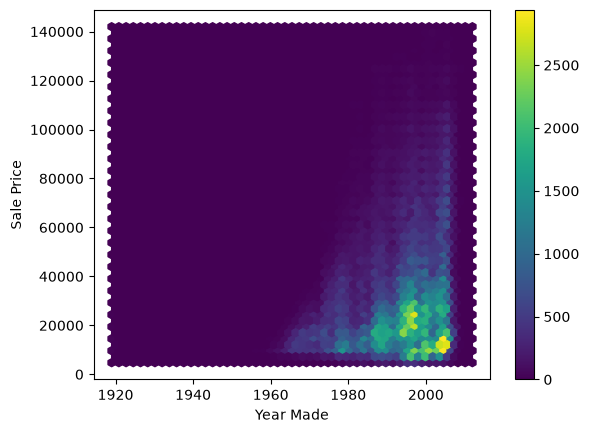

In [20]:
plt.hexbin(yearrestricted["YearMade"], yearrestricted["SalePrice"], gridsize=50)
plt.xlabel("Year Made") 
plt.ylabel("Sale Price") 
plt.colorbar()
plt.show()

In [21]:
yearrestricted.groupby("YearMade")["SalePrice"].mean()



YearMade
1919    17407.480315
1920    29014.705882
1937    18000.000000
1942    51000.000000
1947     9000.000000
            ...     
2008    49439.946777
2009    49522.594340
2010    53688.793103
2011    64764.516129
2012    35000.000000
Name: SalePrice, Length: 70, dtype: float64

In [22]:

with pd.option_context('display.max_rows', None):
    print(yearrestricted.value_counts("YearMade").sort_index())

YearMade
1919      127
1920       17
1937        1
1942        1
1947        1
1948        3
1949        1
1950        8
1951        7
1952        6
1953        7
1954        3
1955        5
1956       20
1957       16
1958       25
1959       28
1960       97
1961       99
1962      145
1963      250
1964      418
1965      675
1966      951
1967     1104
1968     1260
1969     1544
1970     1321
1971     1720
1972     2141
1973     2547
1974     3113
1975     3240
1976     2718
1977     4425
1978     5693
1979     5613
1980     4744
1981     4190
1982     3048
1983     4603
1984     6174
1985     6547
1986     7588
1987    10191
1988    10546
1989    10785
1990    10379
1991     7461
1992     7711
1993    11181
1994    14471
1995    15806
1996    17001
1997    19269
1998    21751
1999    19274
2000    17238
2001    13385
2002    12473
2003    14661
2004    20914
2005    22096
2006    13426
2007     5048
2008     1691
2009      212
2010       58
2011       31
2012        1
Name: count

Certaines années possèdent trop peu d'observation. On va appliquer un seuil de 50 pour avoir une moyenne qui a du sens

In [23]:
tableau = yearrestricted.groupby("YearMade")["SalePrice"].agg(["mean", "count"]).sort_index()
tableau[tableau["count"] >= 50]

,mean,count
YearMade,,
1919,17407.480315,127
1960,11194.329897,97
1961,11948.989899,99
1962,11756.551724,145
1963,13174.500000,250
1964,12549.162679,418
1965,13163.887407,675
1966,13930.178759,951
1967,14053.170290,1104


1919 première année avant la prochaine. On test si c'est une donnée sentinelle 


In [24]:
yearrestricted[yearrestricted["YearMade"]==1919].isnull().sum()

SalesID                       0
SalePrice                     0
MachineID                     0
ModelID                       0
datasource                    0
auctioneerID                  0
YearMade                      0
MachineHoursCurrentMeter    126
UsageBand                   126
saledate                      0
fiModelDesc                   0
fiBaseModel                   0
fiSecondaryDesc              30
fiModelSeries                87
fiModelDescriptor           122
ProductSize                   8
fiProductClassDesc            0
state                         0
ProductGroup                  0
ProductGroupDesc              0
Drive_System                124
Enclosure                     0
Forks                       102
Pad_Type                    124
Ride_Control                103
Stick                       124
Transmission                 39
Turbocharged                124
Blade_Extension             127
Blade_Width                 127
Enclosure_Type              127
Engine_H

Exploration de MachineHoursCurrentMeter


Potentiellement sentinelle car de nombreuses valeurs manquante. Quasi totalité pour heures utilisées mais pas pour les variables obligatoires. 

`HoursRestricted` = `df` filtré sur `MachineHoursCurrentMeter` (exclusion 0 et NaN), pour explorer la relation heures/prix sans bruit.

In [25]:
HoursRestricted = df[(df["MachineHoursCurrentMeter"]!=0)& (df["MachineHoursCurrentMeter"].notnull())]

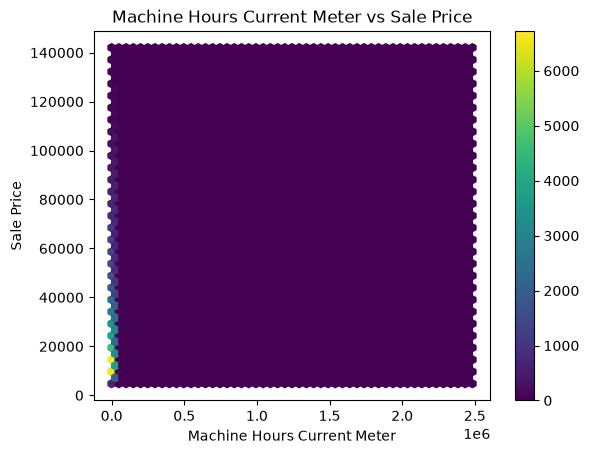

In [26]:
plt.hexbin(HoursRestricted["MachineHoursCurrentMeter"], HoursRestricted["SalePrice"], gridsize=50)
plt.title("Machine Hours Current Meter vs Sale Price")
plt.xlabel("Machine Hours Current Meter")
plt.ylabel("Sale Price")
plt.colorbar()


Des valeurs extrêmes réduisent la lisibilité du graph

In [27]:
HoursRestricted["MachineHoursCurrentMeter"].describe()

count    7.367000e+04
mean     7.053819e+03
std      3.812030e+04
min      1.000000e+00
25%      1.600000e+03
50%      3.213000e+03
75%      6.411000e+03
max      2.483300e+06
Name: MachineHoursCurrentMeter, dtype: float64

Valeurs extrême observée grâce au max. Voir plus en détail grâce aux quantiles et histo de distribution

In [28]:
HoursRestricted["MachineHoursCurrentMeter"].quantile(0.99)

np.float64(32767.0)

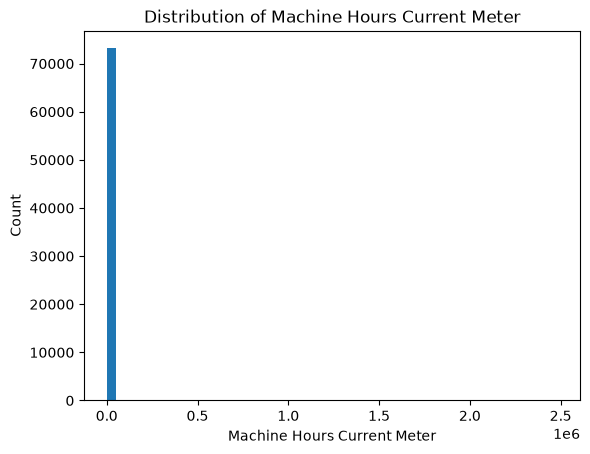

In [29]:
plt.hist(HoursRestricted["MachineHoursCurrentMeter"], bins=50)
plt.title("Distribution of Machine Hours Current Meter")
plt.xlabel("Machine Hours Current Meter")
plt.ylabel("Count")
plt.show()

`HoursRestricted2` = `HoursRestricted` filtré en plus sur le 99e percentile, pour la lisibilité des graphiques uniquement (le seuil de nettoyage final retenu reste 40 000h, voir TODO).

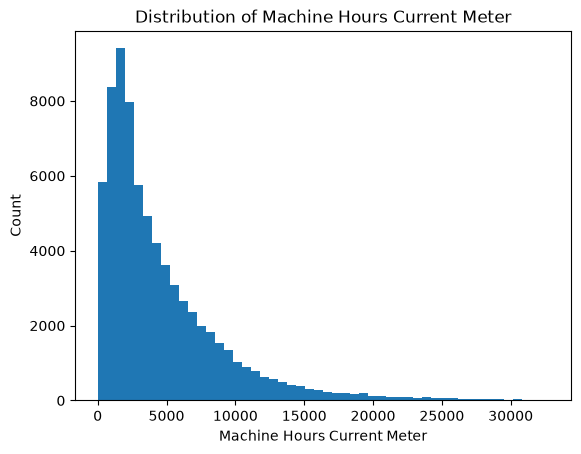

In [30]:
HoursRestricted2 = HoursRestricted[HoursRestricted["MachineHoursCurrentMeter"] < HoursRestricted["MachineHoursCurrentMeter"].quantile(0.99)]
plt.hist(HoursRestricted2["MachineHoursCurrentMeter"], bins=50)
plt.title("Distribution of Machine Hours Current Meter")
plt.xlabel("Machine Hours Current Meter")
plt.ylabel("Count")
plt.show()

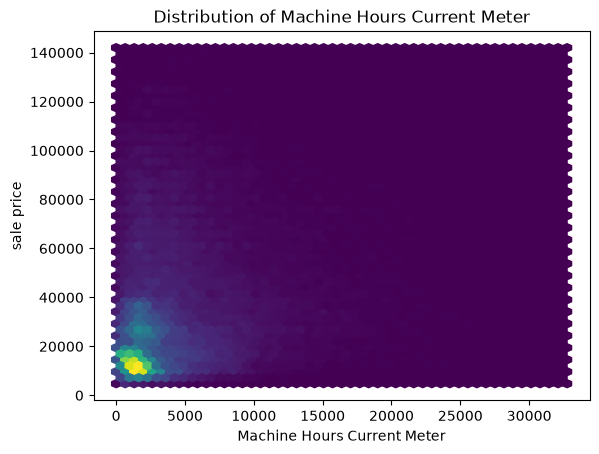

In [31]:
plt.hexbin(HoursRestricted2["MachineHoursCurrentMeter"], HoursRestricted2["SalePrice"], gridsize=50)
plt.title("Distribution of Machine Hours Current Meter")
plt.xlabel("Machine Hours Current Meter")
plt.ylabel("sale price")
plt.show()

In [32]:
HoursRestricted2["hours_bin"] = pd.cut(HoursRestricted2["MachineHoursCurrentMeter"], bins=10)

In [33]:
HoursRestricted2.groupby("hours_bin")["SalePrice"].agg(["mean", "count"]).sort_index()

,mean,count
hours_bin,,
"(-31.754, 3276.4]",30429.545028,37332
"(3276.4, 6551.8]",39390.899865,18495
"(6551.8, 9827.2]",40020.422894,9059
"(9827.2, 13102.6]",42300.057633,3904
"(13102.6, 16378.0]",44212.070787,1893
"(16378.0, 19653.4]",45998.988878,989
"(19653.4, 22928.8]",46521.768953,554
"(22928.8, 26204.2]",46063.846154,325
"(26204.2, 29479.6]",47072.751323,189


une grosse excavatrice utilisée en continu sur un chantier accumule naturellement plus d'heures qu'une petite tondeuse professionnelle utilisée occasionnellement et la grosse excavatrice coûte aussi plus cher à l'achat, indépendamment de son usure.Dans ce cas, MachineHoursCurrentMeter ne serait pas la vraie cause du prix élevé, mais un simple effet indirect du type/taille de machine (confusion entre corrélation et causalité).

Test de la repartition par productgroup

In [34]:
HoursRestricted2.groupby("ProductGroup")["MachineHoursCurrentMeter"].agg(["mean", "count"]).sort_index()

,mean,count
ProductGroup,,
BL,3311.185974,13061
MG,7107.121192,2987
SSL,1814.826925,11209
TEX,4976.302628,20854
TTT,4735.637584,13410
WL,7589.381339,11339


Exploration: fiBaseModel

In [35]:
df["ProductGroup"].value_counts( )

ProductGroup
TEX    104230
TTT     82582
BL      81401
WL      73216
SSL     45011
MG      26258
Name: count, dtype: int64

In [36]:
df["ProductGroup"].isnull().sum()

np.int64(0)

In [37]:
df.groupby("ProductGroup")["SalePrice"].agg(["mean", "count"]).sort_index()

,mean,count
ProductGroup,,
BL,20951.582327,81401
MG,47561.957422,26258
SSL,10583.944014,45011
TEX,35763.457018,104230
TTT,36280.132780,82582
WL,37259.292422,73216


Exploration de ProductSize

In [38]:
df["ProductSize"].value_counts()

ProductSize
Medium            64342
Large / Medium    51297
Small             27057
Mini              25721
Large             21396
Compact            6280
Name: count, dtype: int64

In [39]:
df["ProductSize"].isnull().sum()


np.int64(216605)

In [40]:
df.groupby("ProductGroup")["ProductSize"] \
  .apply(lambda x: x.isnull().mean() * 100) \
  .sort_values(ascending=False)

ProductGroup
BL     100.000000
MG     100.000000
SSL    100.000000
TTT     48.875058
WL      31.984812
TEX      0.148710
Name: ProductSize, dtype: float64

ProductGroup capture déjà l'essentiel de l'info, ProductSize est redondante et à 52% de NaN pas assez de valeur ajoutée pour la complexité qu'elle apporterait.

Exploration de enclosure

In [41]:
df["Enclosure"].value_counts()


Enclosure
OROPS                  177971
EROPS                  141769
EROPS w AC              92601
EROPS AC                   18
NO ROPS                     3
None or Unspecified         2
Name: count, dtype: int64

In [42]:
df["Enclosure"].isnull().sum()

np.int64(334)

In [43]:
df.groupby("Enclosure")["SalePrice"].agg(["mean", "count"]).sort_index()

,mean,count
Enclosure,,
EROPS,28687.993278,141769
EROPS AC,23500.000000,18
EROPS w AC,51671.169728,92601
NO ROPS,44333.333333,3
None or Unspecified,16500.000000,2
OROPS,22592.082739,177971


Enclosure : candidate confirmée, fort pouvoir explicatif (climatisation = facteur clé)

Exploration de hydraulics

In [44]:
df ["Hydraulics"].value_counts()

Hydraulics
2 Valve                145317
Standard               106515
Auxiliary               43224
Base + 1 Function       25511
3 Valve                  5807
4 Valve                  3077
Base + 3 Function         311
Base + 2 Function         132
Base + 5 Function          94
Base + 4 Function          81
Base + 6 Function          54
None or Unspecified        10
Name: count, dtype: int64

In [45]:
df["Hydraulics"].isnull().sum()

np.int64(82565)

In [46]:
df["Hydraulics"].nunique()

12

On veut tester si les valeurs manquantes sont structurelles en croisant avec groupe engin

In [47]:
df.groupby("ProductGroup")["Hydraulics"].apply(lambda x: x.isnull().mean() * 100).sort_values(ascending=False)

ProductGroup
BL     100.000000
WL       0.494427
TEX      0.392401
TTT      0.330581
MG       0.198035
SSL      0.151074
Name: Hydraulics, dtype: float64

ces catégories décrivent probablement des configurations de valves/circuits auxiliaires pour piloter des attachements interchangeables (comme sur une excavatrice qui peut recevoir différents outils). Une tractopelle a une configuration hydraulique fixe et standardisée (godet avant + pelle arrière, toujours pareil) donc l'info n'a jamais eu besoin d'être précisée, contrairement aux excavatrices où le nombre de circuits/valves varie selon les attachements possibles.

In [48]:
taux_nan = df.isnull().sum().sort_values(ascending=False)/len(df)

au-delà de 70% de NaN, une variable est exclue par défaut du modèle, sauf si elle a un lien métier fort et justifiable (comme MachineHoursCurrentMeter).

Epxloration fiProductClassDesc

In [49]:
df["fiProductClassDesc"].unique()[:10]

<StringArray>
[                  'Wheel Loader - 110.0 to 120.0 Horsepower',
                   'Wheel Loader - 150.0 to 175.0 Horsepower',
 'Skid Steer Loader - 1351.0 to 1601.0 Lb Operating Capacity',
      'Hydraulic Excavator, Track - 12.0 to 14.0 Metric Tons',
 'Skid Steer Loader - 1601.0 to 1751.0 Lb Operating Capacity',
    'Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth',
      'Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons',
        'Hydraulic Excavator, Track - 3.0 to 4.0 Metric Tons',
                   'Wheel Loader - 350.0 to 500.0 Horsepower',
        'Track Type Tractor, Dozer - 20.0 to 75.0 Horsepower']
Length: 10, dtype: str

In [50]:
df["fiProductClassDesc"].value_counts()

fiProductClassDesc
Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth             57542
Track Type Tractor, Dozer - 20.0 to 75.0 Horsepower                 18131
Wheel Loader - 150.0 to 175.0 Horsepower                            15537
Track Type Tractor, Dozer - 85.0 to 105.0 Horsepower                15161
Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons               13736
                                                                    ...  
Hydraulic Excavator, Track - Unidentified (Compact Construction)       38
Wheel Loader - 1000.0 + Horsepower                                     25
Hydraulic Excavator, Track - 150.0 to 300.0 Metric Tons                21
Hydraulic Excavator, Track - 300.0 + Metric Tons                        1
Motorgrader - Unidentified                                              1
Name: count, Length: 74, dtype: int64

In [51]:


with pd.option_context('display.max_rows', None):
    print(df.groupby("fiProductClassDesc")["SalePrice"].agg(["mean", "count"]).sort_index())

                                                            mean  count
fiProductClassDesc                                                     
Backhoe Loader - 0.0 to 14.0 Ft Standard Diggin...  16853.891403   4199
Backhoe Loader - 14.0 to 15.0 Ft Standard Diggi...  21760.678374  57542
Backhoe Loader - 15.0 to 16.0 Ft Standard Diggi...  20467.420301  10847
Backhoe Loader - 16.0 + Ft Standard Digging Depth   19848.666604   5306
Backhoe Loader - Unidentified                       15748.552894   3507
Hydraulic Excavator, Track - 0.0 to 2.0 Metric ...  10886.211236   2225
Hydraulic Excavator, Track - 11.0 to 12.0 Metri...  27400.732197   2289
Hydraulic Excavator, Track - 12.0 to 14.0 Metri...  31291.153379  11527
Hydraulic Excavator, Track - 14.0 to 16.0 Metri...  40017.113032   4742
Hydraulic Excavator, Track - 150.0 to 300.0 Met...  38714.285714     21
Hydraulic Excavator, Track - 16.0 to 19.0 Metri...  33910.372633   5810
Hydraulic Excavator, Track - 19.0 to 21.0 Metri...  39842.939245

## 4 - Les transformations

Supression des variables > 70% de manquant

In [52]:
df = df.drop(columns=taux_nan[taux_nan > 0.7].index)

In [53]:
df.columns.tolist()


['SalesID',
 'SalePrice',
 'MachineID',
 'ModelID',
 'datasource',
 'auctioneerID',
 'YearMade',
 'MachineHoursCurrentMeter',
 'saledate',
 'fiModelDesc',
 'fiBaseModel',
 'fiSecondaryDesc',
 'ProductSize',
 'fiProductClassDesc',
 'state',
 'ProductGroup',
 'ProductGroupDesc',
 'Enclosure',
 'Forks',
 'Ride_Control',
 'Transmission',
 'Hydraulics',
 'Coupler']

On applique les modification sur la colonne YearMade. justification, rappel: 9% de NaN sur les autres colonnes → ligne mal collectée, pas juste une année suspecte)

In [54]:
df = traitement_valeurs_incohérentes(df, "YearMade")
with pd.option_context('display.max_rows', None):
    print(df["YearMade"].value_counts())

import pandas as pd

YearMade
2005.0    22096
1998.0    21751
2004.0    20914
1999.0    19274
1997.0    19269
2000.0    17238
1996.0    17001
1995.0    15806
2003.0    14661
1994.0    14471
2006.0    13426
2001.0    13385
2002.0    12473
1993.0    11181
1989.0    10785
1988.0    10546
1990.0    10379
1987.0    10191
1992.0     7711
1986.0     7588
1991.0     7461
1985.0     6547
1984.0     6174
1978.0     5693
1979.0     5613
2007.0     5048
1980.0     4744
1983.0     4603
1977.0     4425
1981.0     4190
1975.0     3240
1974.0     3113
1982.0     3048
1976.0     2718
1973.0     2547
1972.0     2141
1971.0     1720
2008.0     1691
1969.0     1544
1970.0     1321
1968.0     1260
1967.0     1104
1966.0      951
1965.0      675
1964.0      418
1963.0      250
2009.0      212
1962.0      145
1961.0       99
1960.0       97
2010.0       58
2011.0       31
1959.0       28
1958.0       25
1956.0       20
1920.0       17
1957.0       16
1950.0        8
1953.0        7
1951.0        7
1952.0        6
1955.0        5

In [55]:
df["YearMade"].isna().sum()

np.int64(39521)

In [56]:
df.shape[1]

23

In [57]:
df = zero_vers_nan(df, "MachineHoursCurrentMeter")
df["MachineHoursCurrentMeter"].isna().sum()

np.int64(339028)


On crée la colonne binaire hours_reported car l'absence d'information semble être une information


In [58]:

df = Transformation_binaire(df,"MachineHoursCurrentMeter", "hours_reported")
df["hours_reported"].value_counts()

hours_reported
0    339028
1     73670
Name: count, dtype: int64

Transformation de la colonne MachineHoursCurrentMeter. NaN pour les valeurs supp à 40 000h. Justification: 40 000 / 25 = 1600h/an. ~250 jours ouvrés : 1600 / 250 ≈ 6,4h/jour. C'est cohérent avec un usage professionnel quotidien réaliste

In [59]:
df = remplacer_au_dessus_seuil(df, "MachineHoursCurrentMeter", 40000)
df["MachineHoursCurrentMeter"].isna().sum()

np.int64(339635)

In [60]:
(df["MachineHoursCurrentMeter"] > 40000).sum()


np.int64(0)

In [61]:
df["MachineHoursCurrentMeter"].isna().sum()


np.int64(339635)

On effectue le split temporel avant les regroupement pour eviter la fuite de données

In [62]:
train = df[df["saledate"] < "2012-01-01"]
test = df[df["saledate"] >= "2012-01-01"]

In [63]:
train_backup = train.copy(); test_backup = test.copy()

In [64]:
test.shape[0]

11573

Hydraulics : 500 est une valeur raisonnable et pas figée. Une catégorie trop faible provoquerait une modélisation type gradient boosting instable (une feuille sous-alimentée). Ce seuil, fixé initialement pour fiProductClassDesc, a été réappliqué à Hydraulics par cohérence ; vérification faite, il ne regroupe que 0,21% des observations, ce qui reste marginal. De plus, la distribution présente un écart net entre '4 Valve' (3077 occurrences) et 'Base + 3 Function' (311 occurrences), sans catégorie intermédiaire : le choix précis du seuil dans cette plage n'aurait donc pas modifié le résultat du regroupement.

In [65]:
train, test = regrouper_categories_rares(train, test, "Hydraulics", 500)

Enclosure: climatisation = facteur de prix dominant, fusion des libellés synonymes

In [66]:
df["Enclosure"].value_counts()

Enclosure
OROPS                  177971
EROPS                  141769
EROPS w AC              92601
EROPS AC                   18
NO ROPS                     3
None or Unspecified         2
Name: count, dtype: int64

In [67]:
mapping_enclosure = {"NO ROPS": "OROPS", "EROPS AC": "EROPS w AC", "None or Unspecified": np.nan}
train = fusionner_categories(train, "Enclosure", mapping_enclosure)
train["Enclosure"].value_counts()

Enclosure
OROPS         173935
EROPS         139026
EROPS w AC     87837
Name: count, dtype: int64

In [68]:
mapping_enclosure = {"NO ROPS": "OROPS", "EROPS AC": "EROPS w AC", "None or Unspecified": np.nan}
test = fusionner_categories(test, "Enclosure", mapping_enclosure)
test["Enclosure"].value_counts()

Enclosure
EROPS w AC    4782
OROPS         4039
EROPS         2743
Name: count, dtype: int64

fiProductClassDesc est redondante avec ProductGroup. Attention lors de l'utilisation ces variables lors de la modélisation. 

Synthèse: Étape 4 (Préparation)

- Colonnes : 53 →23 après exclusion >70% NaN, 
  puis 24 avec hours_reported.

- YearMade : 39521 NaN créés 
  (sentinelles 1000/1919 + incohérence temporelle >2012).

- MachineHoursCurrentMeter : zéros→NaN, puis seuil 40000h → 
  339635 NaN au total. hours_reported créé en indicateur binaire.

- Enclosure : 6 catégories → 3 (OROPS, EROPS, EROPS w AC), 
  climatisation = facteur de prix dominant.

- Hydraulics et fiProductClassDesc : catégories <500 occurrences sur train 
  regroupées en "Other", mapping figé appliqué à test sans recalcul.

- MachineID : conservé dans le dataframe pour l'instant, 
  exclusion de X à faire à l'étape 6+.

- Anti-fuite : tous les seuils/mappings ci-dessus calculés sur train uniquement.

- Industrialisation : les 6 transformations sont dans src/preprocessing.py 
  (regrouper_categories_rares, traitement_valeurs_incohérentes, zero_vers_nan, 
  Transformation_binaire, remplacer_au_dessus_seuil, fusionner_categories).